<a href="https://colab.research.google.com/github/vvrgit/ML-Optimization/blob/main/ADAMAX_NS_UDEMY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import math as mt
import random

In [2]:
data=[[0.2,3.4],[0.4,3.8]]
data=pd.DataFrame(data,columns=["x","y"])
data.head()

,x,y
0,0.2,3.4
1,0.4,3.8


In [3]:
eta=0.1
beta1=0.9
beta2=0.999
epochs=100
Ns=data.shape[0]
m=random.uniform(-1,1)
c=random.uniform(-1,1)
Em1=0
Ec1=0
Um=0
Uc=0

In [4]:
for iter in range(epochs):
  #Compute Gradients
  gm=0
  gc=0
  for sample in range(Ns):
    x=data.iloc[sample,0]
    y=data.iloc[sample,1]
    gm=gm+(y-m*x-c)*x
    gc=gc+(y-m*x-c)
  gm=(-1/Ns)*gm
  gc=(-1/Ns)*gc

  #Update first moment
  Em1=beta1*Em1+(1-beta1)*gm
  Ec1=beta1*Ec1+(1-beta1)*gc

  #Update infinity norms
  Um=max(beta2*Um,abs(gm))
  Uc=max(beta2*Uc,abs(gc))

  #Update parameters
  m=m-(eta*Em1)/Um
  c=c-(eta*Ec1)/Uc
print(m,c)

1.9335727422710196 3.0395870469115716


In [5]:
yp=np.zeros(Ns)
for sample in range(Ns):
  x=data["x"].iloc[sample]
  yp[sample]=m*x+c
print(yp)

[3.4263016  3.81301614]


In [6]:
ya=data["y"]
print(ya)

0    3.4
1    3.8
Name: y, dtype: float64


In [9]:
e=ya-yp
se=np.square(e)
mse=np.mean(se)
print(mse)

0.00043059695936368495


In [11]:
x=input("enter x value")
x=float(x)
y=m*x+c
print(y)

enter x value0.4
3.813016143819979


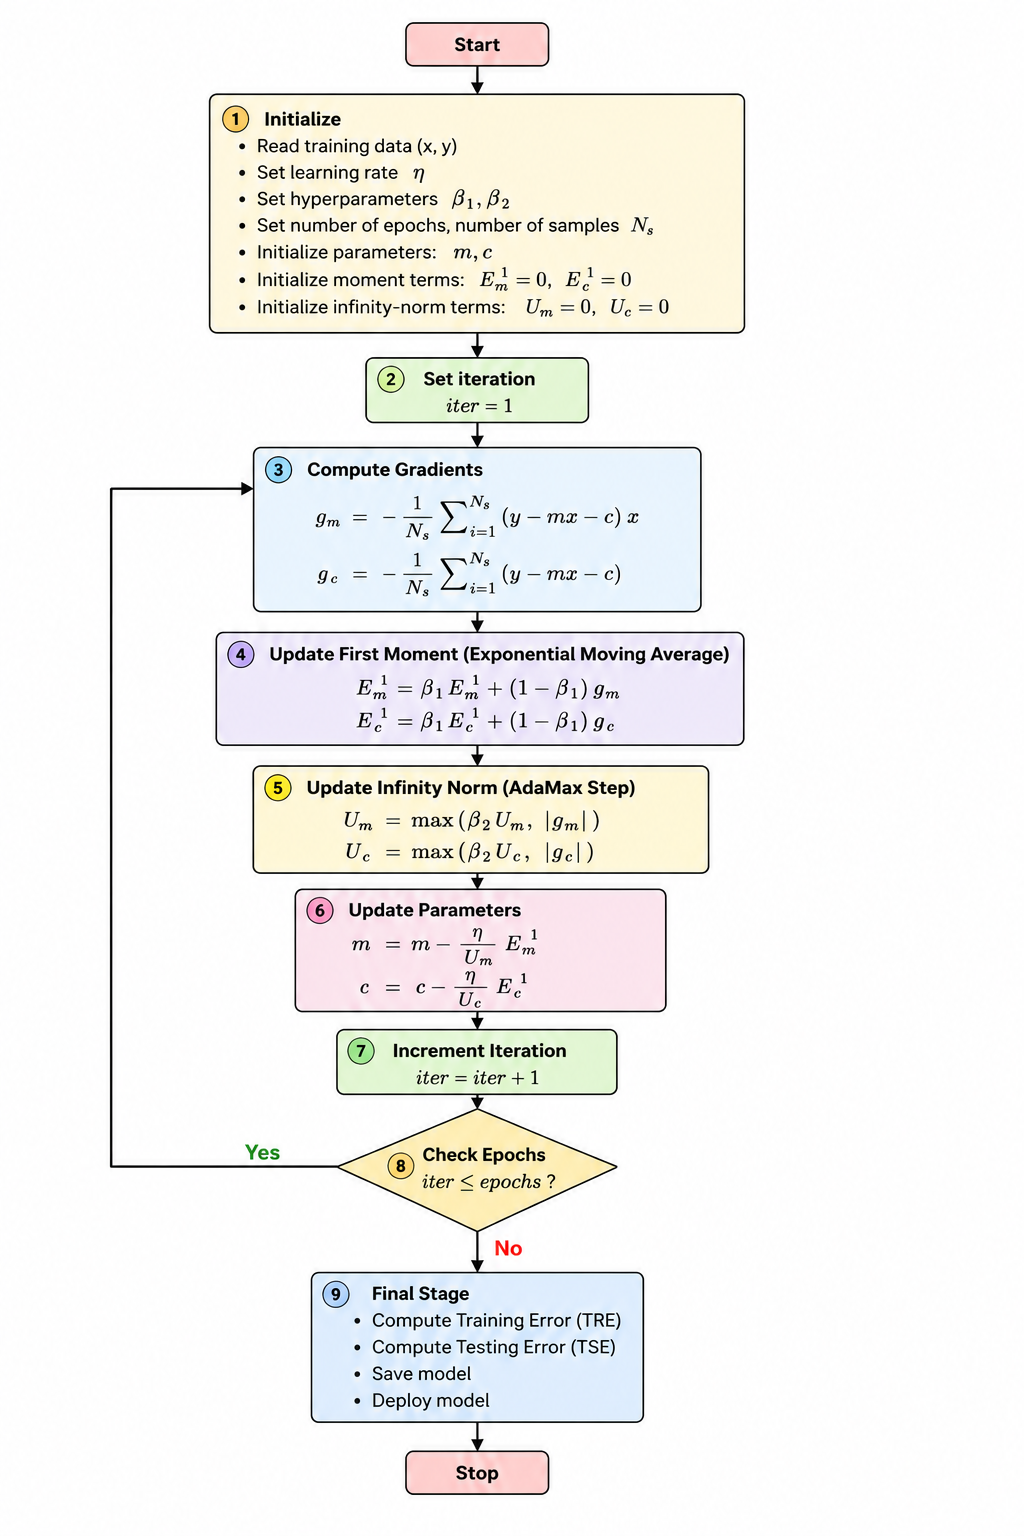